# 04 — Intent Classifier

Map `customer_text → (intent, confidence)` on the frozen taxonomy and
evaluate against the frozen golden set.

## Hard rules (read before running)

1. **Test is evaluated once.** After Cell 12 runs, you cannot re-run test
   with a different classifier. The `TEST_LOCK.json` file enforces this.
2. **No cross-text leakage.** Normalized `customer_text` must be disjoint
   across training / examples / dev / test. Asserted in Cells 4 and 11.
3. **Test is not loaded until Cell 11.** Cells 2–10 never read test labels.
4. **`chosen.json` is immutable before test.** Written in Cell 10, read (not
   modified) in Cell 12. Provenance: model, prompt SHA, taxonomy SHA,
   training data SHA.
5. **Two headline metrics.** Operational macro F1 (9 intents) is primary.
   All-class macro F1 (11 incl. `other`, `ambiguous`) is secondary.
   `ambiguous` has 1 test example — its per-class metrics are reported with
   a support warning.
6. **Rules emit `heuristic_confidence`, not probabilistic confidence.**
   TF-IDF+LR emits `predict_proba`. LLM emits raw + calibrated.
7. **Dry-run is mandatory** before full LLM dev pass.
8. **Bootstrap CIs** on the headline macro F1 (n=1000, seed=42).
9. **Provider is Groq.** Structured Outputs (strict mode) guarantee valid
   JSON on `openai/gpt-oss-20b` and `openai/gpt-oss-120b`. Fallback to JSON
   object mode for other models. Cache key includes model + prompt SHA +
   taxonomy SHA + few-shot SHA so switching models invalidates the cache.

## Approach slate

| Cell | Approach | Training data | Cost |
|---|---|---|---|
| 6 | `rules` | taxonomy patterns | free |
| 7 | `tfidf_lr_rule_labels` | 300 rule-labeled coverage rows | free |
| 7 | `tfidf_lr_human_labels` | ~217 human-verified rows | free |
| 8 | `llm_zeroshot` | none (few-shot from examples) | API |

Whatever runs on dev is compared in Cell 9. Winner is locked in Cell 10.
Winner runs on test once in Cell 12.

## Expected outcome

Compare approaches empirically on the locked protocol. **No performance
target is assumed before the dev experiment.**

In [18]:
# ============ CELL 1b: Bootstrap ============
# Idempotent. Safe to run multiple times. Defines paths, SHAs, and helpers
# so any downstream cell can be run after a kernel restart.

from pathlib import Path
import os, re, json, hashlib, sys, time
from datetime import datetime, timezone
import numpy as np
import pandas as pd

def _find_root():
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if (parent / "pyproject.toml").exists() or (parent / ".git").exists():
            return parent
    raise RuntimeError("Project root not found")

PROJECT_ROOT = _find_root()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BRAND           = "GWRHelp"
CONFIG_DIR      = PROJECT_ROOT / "configs"
TAX_DIR         = PROJECT_ROOT / "runs" / "taxonomy"
GS_DIR          = PROJECT_ROOT / "runs" / "golden_set"
RUNS_CLASSIFIER = PROJECT_ROOT / "runs" / "classifier"
CACHE_DIR       = PROJECT_ROOT / "cache"

# SHAs
tax_sha    = hashlib.sha256((CONFIG_DIR / "intents.yaml").read_bytes()).hexdigest()
golden_sha = hashlib.sha256((GS_DIR / "golden_set.jsonl").read_bytes()).hexdigest()

# Taxonomy
import yaml
tax = yaml.safe_load((CONFIG_DIR / "intents.yaml").read_bytes())
INTENT_NAMES        = [i["name"] for i in tax["intents"]]
OPERATIONAL_INTENTS = [n for n in INTENT_NAMES if n not in ("other", "ambiguous")]

# Chosen classifier (if already locked)
CHOSEN_PATH   = RUNS_CLASSIFIER / "chosen.json"
FINAL_PREDS   = RUNS_CLASSIFIER / "predictions_test.jsonl"
FINAL_METRICS = RUNS_CLASSIFIER / "final_metrics.json"

chosen     = None
chosen_sha = None
WINNER     = None
m_op       = None
m_all      = None

if CHOSEN_PATH.exists():
    chosen     = json.loads(CHOSEN_PATH.read_text(encoding="utf-8"))
    chosen_sha = hashlib.sha256(CHOSEN_PATH.read_bytes()).hexdigest()
    WINNER     = chosen["approach"]

if FINAL_METRICS.exists():
    final = json.loads(FINAL_METRICS.read_text(encoding="utf-8"))
    m_op  = final["operational"]["macro_f1"]
    m_all = {
        "macro_f1":    final["overall"]["macro_f1"],
        "weighted_f1": final["overall"]["weighted_f1"],
        "accuracy":    final["overall"]["accuracy"],
    }

print("Bootstrap complete.")
print(f"  PROJECT_ROOT:   {PROJECT_ROOT}")
print(f"  tax_sha:        {tax_sha[:16]}...")
print(f"  golden_sha:     {golden_sha[:16]}...")
if WINNER:
    print(f"  WINNER:         {WINNER}")
    print(f"  chosen_sha:     {chosen_sha[:16]}...")
if m_op is not None:
    print(f"  op_macro_f1:    {m_op:.3f}")

Bootstrap complete.
  PROJECT_ROOT:   D:\CODIN PLAYGROUND\ML-AI\ResolveIQ
  tax_sha:        7a05e4af68a50981...
  golden_sha:     acde341dc09e85ae...
  WINNER:         tfidf_lr_human_labels
  chosen_sha:     f4ce8a0c3f6283df...
  op_macro_f1:    0.503


In [34]:
# ============ CELL 2: Setup + verify frozen inputs ============
from pathlib import Path
import os, re, json, hashlib, sys, time
from datetime import datetime, timezone
from dotenv import load_dotenv
load_dotenv()
import numpy as np
import pandas as pd
from IPython.display import display

# --- Project root ---
def find_project_root():
    markers = [".git", "pyproject.toml"]
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if any((parent / m).exists() for m in markers):
            return parent
    raise RuntimeError(f"Could not locate ResolveIQ project root from {p}")

PROJECT_ROOT = find_project_root()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BRAND          = "GWRHelp"
CONFIG_DIR     = PROJECT_ROOT / "configs"
TAX_DIR        = PROJECT_ROOT / "runs" / "taxonomy"
GS_DIR         = PROJECT_ROOT / "runs" / "golden_set"
RUNS_CLASSIFIER = PROJECT_ROOT / "runs" / "classifier"
CACHE_DIR      = PROJECT_ROOT / "cache"
RUNS_CLASSIFIER.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

INTENTS_YAML   = CONFIG_DIR / "intents.yaml"
INTENTS_SHA    = TAX_DIR / "intents.yaml.sha256"
GOLDEN_JSONL   = GS_DIR / "golden_set.jsonl"
GOLDEN_SHA_F   = GS_DIR / "golden_set.sha256"
GOLDEN_META    = GS_DIR / "golden_set.meta.json"
VERIFICATION   = GS_DIR / "verification_sheet.csv"
EXAMPLES_CSV   = TAX_DIR / "intent_examples.csv"
COVERAGE_CSV   = TAX_DIR / "coverage_labeling_sheet.csv"

for p in (INTENTS_YAML, INTENTS_SHA, GOLDEN_JSONL, GOLDEN_SHA_F, GOLDEN_META,
          VERIFICATION, EXAMPLES_CSV, COVERAGE_CSV):
    assert p.exists(), f"Missing required input: {p}"

# --- Taxonomy SHA ---
tax_bytes = INTENTS_YAML.read_bytes()
tax_sha   = hashlib.sha256(tax_bytes).hexdigest()
assert tax_sha == INTENTS_SHA.read_text(encoding="utf-8").strip(), \
    "Taxonomy SHA mismatch"

import yaml
tax = yaml.safe_load(tax_bytes)
assert tax.get("draft") is False, "Taxonomy is still draft"
INTENT_NAMES        = [i["name"] for i in tax["intents"]]
INTENT_DEFS         = {i["name"]: i for i in tax["intents"]}
OPERATIONAL_INTENTS = [n for n in INTENT_NAMES if n not in ("other", "ambiguous")]

# --- Golden SHA ---
golden_sha = hashlib.sha256(GOLDEN_JSONL.read_bytes()).hexdigest()
golden_meta = json.loads(GOLDEN_META.read_text(encoding="utf-8"))
assert golden_sha == golden_meta["golden_sha256"], "Golden SHA mismatch vs meta"
assert golden_sha == GOLDEN_SHA_F.read_text(encoding="utf-8").strip(), \
    "Golden SHA mismatch vs .sha256 file"
assert golden_meta["taxonomy_sha256"] == tax_sha, "Golden pinned to different taxonomy"

print(f"PROJECT_ROOT:        {PROJECT_ROOT}")
print(f"Taxonomy SHA:        {tax_sha[:16]}...")
print(f"Golden SHA:          {golden_sha[:16]}...")
print(f"Intents:             {len(INTENT_NAMES)} ({len(OPERATIONAL_INTENTS)} operational)")
print(f"Golden:              {golden_meta['golden_size']} rows "
      f"({golden_meta['dev_size']} dev / {golden_meta['test_size']} test)")

PROJECT_ROOT:        D:\CODIN PLAYGROUND\ML-AI\ResolveIQ
Taxonomy SHA:        7a05e4af68a50981...
Golden SHA:          acde341dc09e85ae...
Intents:             11 (9 operational)
Golden:              198 rows (59 dev / 139 test)


In [2]:
# ============ CELL 3: Load DEV only ============
# Test labels are NEVER loaded here. We only record the test root_ids
# (from meta) so the training pool can exclude them.
TEST_ROOT_IDS = set(int(x) for x in golden_meta["test_root_ids"])

dev_rows = []
with open(GOLDEN_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        if r["split"] == "dev":
            dev_rows.append(r)
        # Test rows are silently skipped. They are reloaded in Cell 11.

dev_df = pd.DataFrame(dev_rows)
DEV_ROOT_IDS = set(dev_df["root_id"].astype(int))

assert len(dev_df) == golden_meta["dev_size"], \
    f"Dev size mismatch: loaded {len(dev_df)}, meta says {golden_meta['dev_size']}"
assert set(dev_df["true_intent"].unique()) <= set(INTENT_NAMES), "Unknown labels in dev"
assert (dev_df["taxonomy_sha256"] == tax_sha).all(), \
    "Some dev rows pinned to a different taxonomy"

print(f"Dev rows:       {len(dev_df)}")
print(f"Test root_ids:  {len(TEST_ROOT_IDS)} (labels not loaded)")
print(f"Dev intent distribution:")
print(dev_df["true_intent"].value_counts().to_string())

Dev rows:       59
Test root_ids:  139 (labels not loaded)
Dev intent distribution:
true_intent
delay_compensation    15
service_disruption     8
on_board_issue         7
refund_request         6
seat_reservation       5
praise_or_chatter      5
other                  5
timetable_info         4
booking_issue          3
lost_property          1


In [3]:
# ============ CELL 4: Training pools + leakage checks ============
# Two training regimes:
#   A. rule_labels  — 300 rule-labeled coverage rows (imitation baseline)
#   B. human_labels — human-verified annotation rows NOT in golden (real labels)
#
# Both are disjoint from golden dev and golden test by root_id.
# Both are ALSO disjoint by normalized text from dev and examples.

def norm_text(t: str) -> str:
    return re.sub(r"\s+", " ", str(t).lower()).strip()

GOLDEN_ROOT_IDS = DEV_ROOT_IDS | TEST_ROOT_IDS

# --- Regime A: rule-labeled ---
coverage = pd.read_csv(COVERAGE_CSV, encoding="utf-8")
coverage = coverage.rename(columns={"intent": "true_intent"})
coverage = coverage[["root_id", "customer_text", "true_intent"]].copy()
coverage = coverage[~coverage["root_id"].astype(int).isin(GOLDEN_ROOT_IDS)]
coverage = coverage[coverage["true_intent"].isin(INTENT_NAMES)]
coverage["true_intent"] = coverage["true_intent"].astype(str)
coverage["_src"] = "rule_labels"

# --- Regime B: human-labeled ---
verification = pd.read_csv(VERIFICATION, encoding="utf-8")
human_a = verification[verification["human_confirmed"].astype(str).str.lower() == "y"].copy()
human_a = human_a[["root_id", "customer_text", "true_intent"]].copy()
human_a = human_a[~human_a["root_id"].astype(int).isin(GOLDEN_ROOT_IDS)]
human_a = human_a[human_a["true_intent"].isin(INTENT_NAMES)]
human_a["_src"] = "human_pool"

examples = pd.read_csv(EXAMPLES_CSV, encoding="utf-8")
examples = examples[examples["_keep"].astype(str).str.lower() == "y"]
human_b = examples[["root_id", "customer_text", "intent"]].rename(columns={"intent": "true_intent"})
human_b = human_b[~human_b["root_id"].astype(int).isin(GOLDEN_ROOT_IDS)]
human_b = human_b[human_b["true_intent"].isin(INTENT_NAMES)]
human_b["_src"] = "human_examples"

human_pool = pd.concat([human_a, human_b], ignore_index=True)
human_pool = human_pool.drop_duplicates(subset=["root_id"])

# --- Cross-text leakage check ---
train_texts_A = set(coverage["customer_text"].map(norm_text))
train_texts_B = set(human_pool["customer_text"].map(norm_text))
dev_texts     = set(dev_df["customer_text"].map(norm_text))

# Examples used for few-shot must also be disjoint from dev
examples_texts = set(examples["customer_text"].map(norm_text))

overlap_A = train_texts_A & dev_texts
overlap_B = train_texts_B & dev_texts
overlap_AB = train_texts_A & train_texts_B
overlap_ex = examples_texts & dev_texts

assert not overlap_A,  f"Text leak A/dev: {len(overlap_A)}"
assert not overlap_B,  f"Text leak B/dev: {len(overlap_B)}"
assert not overlap_ex, f"Text leak examples/dev: {len(overlap_ex)}"

# A and B may share text (both derived from same corpus). Drop from B if so.
if overlap_AB:
    human_pool = human_pool[~human_pool["customer_text"].map(norm_text).isin(overlap_AB)]
    print(f"Dropped {len(overlap_AB)} rows from human_pool to avoid A/B text overlap.")

print(f"Regime A (rule_labels):   {len(coverage)} rows")
print(f"Regime B (human_labels):  {len(human_pool)} rows")
print(f"  ├ human_pool:           {len(human_a)}")
print(f"  └ human_examples:       {len(human_b)}")
print(f"Dev rows (label only):    {len(dev_df)}")
print(f"Test root_ids (no labels): {len(TEST_ROOT_IDS)}")
print()
print("Regime A distribution:")
print(coverage["true_intent"].value_counts().to_string())
print()
print("Regime B distribution:")
print(human_pool["true_intent"].value_counts().to_string())

Dropped 19 rows from human_pool to avoid A/B text overlap.
Regime A (rule_labels):   300 rows
Regime B (human_labels):  188 rows
  ├ human_pool:           112
  └ human_examples:       95
Dev rows (label only):    59
Test root_ids (no labels): 139

Regime A distribution:
true_intent
on_board_issue        63
delay_compensation    59
service_disruption    48
other                 34
praise_or_chatter     30
timetable_info        24
seat_reservation      15
booking_issue         12
refund_request         7
lost_property          6
ambiguous              2

Regime B distribution:
true_intent
on_board_issue        27
delay_compensation    25
service_disruption    25
refund_request        23
booking_issue         18
timetable_info        18
seat_reservation      15
praise_or_chatter     15
other                 14
lost_property          8


In [ ]:
# ============ CELL 5: Metric utilities ============
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support, confusion_matrix,
)

def metrics_block(y_true, y_pred, labels, tag=""):
    """Full metrics for one prediction set."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = list(labels)
    p, r, f1, s = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    macro   = float(f1_score(y_true, y_pred, labels=labels, average="macro",    zero_division=0))
    weighted= float(f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0))
    acc     = float((y_true == y_pred).mean())
    per_intent = pd.DataFrame({
        "intent": labels, "precision": p, "recall": r, "f1": f1, "support": s.astype(int),
    })
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=labels),
        index=[f"true_{l}" for l in labels],
        columns=[f"pred_{l}" for l in labels],
    )
    return {
        "tag": tag, "n": len(y_true),
        "macro_f1": macro, "weighted_f1": weighted, "accuracy": acc,
        "per_intent": per_intent, "confusion": cm,
    }

def operational_metrics(y_true, y_pred):
    """Macro F1 restricted to operational intents only."""
    mask = np.isin(y_true, OPERATIONAL_INTENTS) | np.isin(y_pred, OPERATIONAL_INTENTS)
    return float(f1_score(
        np.asarray(y_true)[mask], np.asarray(y_pred)[mask],
        labels=OPERATIONAL_INTENTS, average="macro", zero_division=0,
    ))

def bootstrap_ci(y_true, y_pred, labels, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    n = len(y_true)
    if n == 0:
        return (0.0, 0.0)
    scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        scores[b] = f1_score(y_true[idx], y_pred[idx],
                             labels=list(labels), average="macro", zero_division=0)
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

def reliability_table(confs, correct, n_bins=10):
    """Reliability diagram data: bucket -> (n, mean_conf, empirical_acc)."""
    confs = np.asarray(confs, dtype=float)
    correct = np.asarray(correct, dtype=bool)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (confs >= lo) & (confs < hi if i < n_bins - 1 else confs <= hi)
        n = int(mask.sum())
        if n == 0:
            rows.append({"bucket": f"[{lo:.1f},{hi:.1f})", "n": 0,
                         "mean_conf": float("nan"),
                         "emp_acc": float("nan"),
                         "gap": float("nan")})
            continue
        mc = float(confs[mask].mean())
        ea = float(correct[mask].mean())
        rows.append({"bucket": f"[{lo:.1f},{hi:.1f})", "n": n,
                     "mean_conf": mc, "emp_acc": ea, "gap": abs(mc - ea)})
    return pd.DataFrame(rows)

def ece(confs, correct, n_bins=10):
    """Expected calibration error."""
    tbl = reliability_table(confs, correct, n_bins)
    total = tbl["n"].sum()
    if total == 0:
        return 0.0
    # Skip rows with missing gap (None OR NaN) — empty buckets
    contribs = []
    for _, row in tbl.iterrows():
        gap = row["gap"]
        if gap is None or pd.isna(gap):
            continue
        contribs.append((row["n"] / total) * gap)
    return float(sum(contribs))

print("Metric utilities loaded.")

Metric utilities loaded.


In [22]:
# ============ CELL 6: Baseline A — taxonomy rules ============
# Rules derived from the taxonomy's include_when patterns + probe regexes.
# NOT reused from the 03 cascade — built fresh from taxonomy, deliberately
# independent of the annotation suggestion path.
#
# Confidence column is called `heuristic_confidence` throughout, not
# "confidence", because it is a symbolic strength signal, not a probability.

RULES = [
    # (regex, intent, heuristic_confidence)
    (r"\b(delay ?repay|claim.*compensation|compensation for|missed.*connection.*(compensat|claim))\b",
     "delay_compensation", "high"),
    (r"\b(refund|money back|reimburse|money returned)\b",
     "refund_request", "high"),
    (r"\b(your website|the website|your app|online booking|booking system|booking form|"
     r"can'?t book|unable to book|checkout|payment fail)\b",
     "booking_issue", "high"),
    (r"\b(lost property|handed in|hand it in|left my|left a|forgot my|forgot a)\b",
     "lost_property", "high"),
    (r"\b(reserved seat|seat reservation|reserve a seat|reserved coach|coach [a-z]\b)\b",
     "seat_reservation", "high"),
    (r"\b(toilet|overcrowd|standing room|packed|crammed|sardines|dirty|rude staff|"
     r"heating|air con)\b",
     "on_board_issue", "high"),
    (r"\b(cancell?ed|no trains|suspended|strike|engineering works|"
     r"line closed|no service)\b",
     "service_disruption", "high"),
    (r"\b(next train|what time|which platform|timetable|when does|"
     r"when will the .* (run|arrive|depart))\b",
     "timetable_info", "high"),
    (r"\b(thank you|thanks|cheers|well done|amazing|fantastic|brilliant|great job|"
     r"love (it|your|the)|super service)\b",
     "praise_or_chatter", "medium"),
]

_RULES_COMPILED = [(re.compile(p, re.I), intent, conf) for p, intent, conf in RULES]

def classify_rules(text: str) -> dict:
    """Returns {'intent', 'confidence', 'alternative_intent', 'alternative_confidence'}."""
    t = str(text)
    for pattern, intent, conf in _RULES_COMPILED:
        if pattern.search(t):
            return {
                "intent": intent,
                "confidence": {"high": 0.9, "medium": 0.6, "low": 0.3}[conf],
                "heuristic_confidence": conf,
                "alternative_intent": "",
                "alternative_confidence": 0.0,
            }
    return {
        "intent": "other",
        "confidence": 0.2,
        "heuristic_confidence": "low",
        "alternative_intent": "",
        "alternative_confidence": 0.0,
    }

# --- Run and evaluate on dev ---
def run_approach(name, predict_fn, df, labels, model_meta=None):
    out_dir = RUNS_CLASSIFIER / name
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    t0 = time.time()
    for _, r in df.iterrows():
        result = predict_fn(r["customer_text"])
        rows.append({
            "root_id": int(r["root_id"]),
            "true_intent": r["true_intent"],
            "pred_intent": result["intent"],
            "confidence": float(result["confidence"]),
            "alternative_intent": result.get("alternative_intent", ""),
            "alternative_confidence": float(result.get("alternative_confidence", 0.0)),
            "split": r["split"],
            "_source": r["_source"],
        })
    elapsed = time.time() - t0

    preds = pd.DataFrame(rows)
    # --- Hard checks ---
    assert len(preds) == len(df), \
        f"[{name}] {len(preds)} predictions != {len(df)} rows"
    assert preds["pred_intent"].isin(INTENT_NAMES).all(), \
        f"[{name}] invalid intent predicted"
    assert ((preds["confidence"] >= 0) & (preds["confidence"] <= 1)).all(), \
        f"[{name}] confidence out of [0,1]"

    # --- Persist ---
    preds.to_json(out_dir / "predictions_dev.jsonl",
                  orient="records", lines=True, force_ascii=False)

    m = metrics_block(preds["true_intent"], preds["pred_intent"],
                      INTENT_NAMES, tag=name)
    m_op = operational_metrics(preds["true_intent"].tolist(),
                               preds["pred_intent"].tolist())

    # Slices
    nat = preds[preds["_source"] == "natural"]
    tgt = preds[preds["_source"].astype(str).str.startswith("targeted:")]
    m_nat = metrics_block(nat["true_intent"], nat["pred_intent"], INTENT_NAMES) if len(nat) else None
    m_tgt = metrics_block(tgt["true_intent"], tgt["pred_intent"], INTENT_NAMES) if len(tgt) else None

    ci = bootstrap_ci(preds["true_intent"].tolist(),
                      preds["pred_intent"].tolist(), INTENT_NAMES)

    m["per_intent"].to_csv(out_dir / "per_intent_dev.csv", index=False)
    m["confusion"].to_csv(out_dir / "confusion_dev.csv")

    (out_dir / "metrics_dev.json").write_text(json.dumps({
        "overall":         {k: m[k] for k in ("macro_f1", "weighted_f1", "accuracy", "n")},
        "operational_macro_f1": m_op,
        "macro_f1_95ci":   list(ci),
        "natural":         ({k: m_nat[k] for k in ("macro_f1","weighted_f1","accuracy","n")}
                            if m_nat else None),
        "targeted":        ({k: m_tgt[k] for k in ("macro_f1","weighted_f1","accuracy","n")}
                            if m_tgt else None),
        "per_intent":      m["per_intent"].to_dict(orient="records"),
        "elapsed_sec":     elapsed,
    }, indent=2), encoding="utf-8")

    (out_dir / "meta.json").write_text(json.dumps({
        "approach": name,
        "model_meta": model_meta or {},
        "taxonomy_sha256": tax_sha,
        "golden_sha256":   golden_sha,
        "dev_size":        len(df),
        "created_at":      datetime.now(timezone.utc).isoformat(timespec="seconds"),
    }, indent=2), encoding="utf-8")

    print(f"[{name}] dev macro_f1={m['macro_f1']:.3f} "
          f"op_macro={m_op:.3f} "
          f"95CI=[{ci[0]:.3f},{ci[1]:.3f}] "
          f"acc={m['accuracy']:.3f}  n={len(df)}  t={elapsed:.1f}s")
    return m

run_approach("rules", classify_rules, dev_df, INTENT_NAMES,
             model_meta={"type": "rules", "n_patterns": len(RULES)})

[rules] dev macro_f1=0.396 op_macro=0.458 95CI=[0.242,0.449] acc=0.390  n=59  t=0.0s


{'tag': 'rules',
 'n': 59,
 'macro_f1': 0.39599239144693693,
 'weighted_f1': 0.3615513488394844,
 'accuracy': 0.3898305084745763,
 'per_intent':                 intent  precision    recall        f1  support
 0   delay_compensation   0.000000  0.000000  0.000000       15
 1       refund_request   1.000000  0.833333  0.909091        6
 2        booking_issue   0.000000  0.000000  0.000000        3
 3       timetable_info   0.000000  0.000000  0.000000        4
 4   service_disruption   0.833333  0.625000  0.714286        8
 5     seat_reservation   0.800000  0.800000  0.800000        5
 6        lost_property   1.000000  1.000000  1.000000        1
 7       on_board_issue   1.000000  0.142857  0.250000        7
 8    praise_or_chatter   0.500000  0.400000  0.444444        5
 9                other   0.135135  1.000000  0.238095        5
 10           ambiguous   0.000000  0.000000  0.000000        0,
 'confusion':                          pred_delay_compensation  pred_refund_request  \


In [23]:
# ============ CELL 7: Baseline B — TF-IDF + LR (two regimes) ============
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def build_pipe():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2), min_df=2, sublinear_tf=True,
            strip_accents="unicode",
        )),
        ("lr", LogisticRegression(
            max_iter=2000, C=1.0, class_weight="balanced", n_jobs=1,
        )),
    ])

def make_predictor(pipe):
    """Return a predict_fn that emits intent + confidence + top-2."""
    classes = list(pipe.classes_)
    def _predict(text):
        probs = pipe.predict_proba([str(text)])[0]
        order = np.argsort(probs)[::-1]
        top1 = order[0]
        top2 = order[1] if len(order) > 1 else None
        return {
            "intent": classes[top1],
            "confidence": float(probs[top1]),
            "alternative_intent": classes[top2] if top2 is not None else "",
            "alternative_confidence": float(probs[top2]) if top2 is not None else 0.0,
        }
    return _predict

# --- Regime A: rule-labeled ---
pipe_A = build_pipe()
pipe_A.fit(coverage["customer_text"].tolist(), coverage["true_intent"].tolist())
run_approach("tfidf_lr_rule_labels", make_predictor(pipe_A), dev_df, INTENT_NAMES,
             model_meta={"type": "tfidf_lr", "regime": "rule_labels",
                         "n_train": len(coverage)})

# --- Regime B: human-labeled ---
pipe_B = build_pipe()
pipe_B.fit(human_pool["customer_text"].tolist(), human_pool["true_intent"].tolist())
run_approach("tfidf_lr_human_labels", make_predictor(pipe_B), dev_df, INTENT_NAMES,
             model_meta={"type": "tfidf_lr", "regime": "human_labels",
                         "n_train": len(human_pool)})

d:\CODIN PLAYGROUND\ML-AI\RingWatch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[tfidf_lr_rule_labels] dev macro_f1=0.434 op_macro=0.470 95CI=[0.306,0.528] acc=0.542  n=59  t=0.0s


d:\CODIN PLAYGROUND\ML-AI\RingWatch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[tfidf_lr_human_labels] dev macro_f1=0.455 op_macro=0.556 95CI=[0.289,0.529] acc=0.508  n=59  t=0.0s


{'tag': 'tfidf_lr_human_labels',
 'n': 59,
 'macro_f1': 0.4548979531384223,
 'weighted_f1': 0.4924598638103285,
 'accuracy': 0.5084745762711864,
 'per_intent':                 intent  precision    recall        f1  support
 0   delay_compensation   0.562500  0.600000  0.580645       15
 1       refund_request   0.833333  0.833333  0.833333        6
 2        booking_issue   0.333333  0.333333  0.333333        3
 3       timetable_info   0.142857  0.250000  0.181818        4
 4   service_disruption   0.500000  0.750000  0.600000        8
 5     seat_reservation   1.000000  0.800000  0.888889        5
 6        lost_property   1.000000  1.000000  1.000000        1
 7       on_board_issue   0.500000  0.142857  0.222222        7
 8    praise_or_chatter   0.333333  0.400000  0.363636        5
 9                other   0.000000  0.000000  0.000000        5
 10           ambiguous   0.000000  0.000000  0.000000        0,
 'confusion':                          pred_delay_compensation  pred_ref

In [24]:
import json
from pathlib import Path
cache_path = Path.cwd().parent / "cache" / "intent_predictions.jsonl"
n = 0
if cache_path.exists():
    with open(cache_path, encoding="utf-8") as f:
        for _ in f:
            n += 1
print(f"Cached LLM responses: {n}")

Cached LLM responses: 59


In [ ]:
# ============ CELL 8: LLM zero-shot classifier (Groq) ============
# Uses Groq's OpenAI-compatible endpoint. Structured Outputs (strict mode)
# is guaranteed valid JSON on gpt-oss-20b/120b; falls back to JSON object
# mode for other models.
#
# Env: GROQ_API_KEY required. RESOLVEIQ_MODEL optional.

LLM_MODEL       = os.environ.get("RESOLVEIQ_MODEL", "openai/gpt-oss-20b")
LLM_CACHE_PATH  = CACHE_DIR / "intent_predictions.jsonl"
LLM_FEWSHOT_PER = 2
LLM_MAX_RETRIES = 3
GROQ_BASE_URL   = "https://api.groq.com/openai/v1"

# Models that support strict structured outputs (constrained decoding).
STRICT_OUTPUT_MODELS = {"openai/gpt-oss-20b", "openai/gpt-oss-120b"}

def _llm_available():
    if not os.environ.get("GROQ_API_KEY"):
        return False
    try:
        import groq  # noqa
        return True
    except ImportError:
        try:
            import openai  # noqa
            return True
        except ImportError:
            return False

def _make_groq_client():
    """Prefer native groq SDK; fall back to openai SDK with base_url."""
    api_key = os.environ["GROQ_API_KEY"]
    try:
        from groq import Groq
        return ("groq", Groq(api_key=api_key))
    except ImportError:
        from openai import OpenAI
        return ("openai", OpenAI(api_key=api_key, base_url=GROQ_BASE_URL))

_GROQ_CLIENT = None
_GROQ_CLIENT_KIND = None
if _llm_available():
    _GROQ_CLIENT_KIND, _GROQ_CLIENT = _make_groq_client()
    print(f"Groq client: {_GROQ_CLIENT_KIND} SDK | model={LLM_MODEL}")

# --- Structured-outputs JSON schema (only used with strict-capable models) ---
LLM_JSON_SCHEMA = {
    "type": "object",
    "properties": {
        "intent": {"type": "string", "enum": INTENT_NAMES},
        "confidence": {"type": "number", "minimum": 0.0, "maximum": 1.0},
        "alternative_intent": {"type": "string"},
        "alternative_confidence": {"type": "number", "minimum": 0.0, "maximum": 1.0},
    },
    "required": ["intent", "confidence",
                 "alternative_intent", "alternative_confidence"],
    "additionalProperties": False,
}

def _call_llm_json(system_prompt: str, user_text: str) -> dict:
    """Return parsed JSON. Raises on failure."""
    assert _GROQ_CLIENT is not None, "Groq client not initialised"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_text},
    ]

    # Try strict structured outputs first for capable models
    if LLM_MODEL in STRICT_OUTPUT_MODELS:
        try:
            resp = _GROQ_CLIENT.chat.completions.create(
                model=LLM_MODEL,
                messages=messages,
                temperature=0,
                response_format={
                    "type": "json_schema",
                    "json_schema": {
                        "name": "intent_classification",
                        "strict": True,
                        "schema": LLM_JSON_SCHEMA,
                    },
                },
            )
            return json.loads(resp.choices[0].message.content)
        except Exception as e:
            # Fall through to json_object mode on any structured-output failure
            pass

    # JSON object mode (works across models). Groq requires the word "JSON"
    # to appear in the prompt when using this mode.
    resp = _GROQ_CLIENT.chat.completions.create(
        model=LLM_MODEL,
        messages=messages,
        temperature=0,
        response_format={"type": "json_object"},
    )
    return json.loads(resp.choices[0].message.content)

# --- Few-shot builder (unchanged) ---
def build_fewshot_examples():
    """2 per operational intent + 2 other + 2 ambiguous, from human_pool
    (never from dev or golden)."""
    pool = human_pool.copy()
    lines = []
    for intent in OPERATIONAL_INTENTS:
        sub = pool[pool["true_intent"] == intent].head(LLM_FEWSHOT_PER)
        for _, r in sub.iterrows():
            lines.append(f'  <ex intent="{intent}">{str(r["customer_text"])[:200]}</ex>')
    for intent in ("other", "ambiguous"):
        sub = pool[pool["true_intent"] == intent].head(LLM_FEWSHOT_PER)
        for _, r in sub.iterrows():
            lines.append(f'  <ex intent="{intent}">{str(r["customer_text"])[:200]}</ex>')
    return "\n".join(lines)

def build_system_prompt():
    parts = [
        f"You are an intent classifier for {BRAND} customer support.",
        "",
        "Available intents (choose exactly one):",
    ]
    for it in tax["intents"]:
        parts.append(f"- {it['name']}: {it['description'].strip()}")
        parts.append(f"  Include when: {' | '.join(it['include_when'])}")
        parts.append(f"  Exclude when: {' | '.join(it['exclude_when'])}")
    parts += [
        "",
        "Rules:",
        "- Respond with a single JSON object and nothing else.",
        "- Do NOT force-fit a message into an operational intent merely "
        "because related words appear. If nothing fits, use \"other\".",
        "- If two intents are genuinely equally plausible, use \"ambiguous\".",
        "- Confidence is a raw score in [0,1]; it is not a calibrated probability.",
        "- Provide an alternative intent and its confidence. If there is no "
        "reasonable alternative, repeat the chosen intent with confidence 0.0.",
        "",
        'Output schema: {"intent": "<name>", "confidence": <float>, '
        '"alternative_intent": "<name>", "alternative_confidence": <float>}',
        "",
        "Few-shot examples:",
        build_fewshot_examples(),
    ]
    return "\n".join(parts)

def parse_llm_response(raw: dict) -> dict:
    """Validate and normalize."""
    intent = str(raw.get("intent", "")).strip()
    conf   = float(raw.get("confidence", 0.0))
    alt    = str(raw.get("alternative_intent", "")).strip()
    altc   = float(raw.get("alternative_confidence", 0.0))
    if intent not in INTENT_NAMES:
        intent = "other"
        conf = 0.0
    if alt not in INTENT_NAMES:
        alt = ""
        altc = 0.0
    # Treat self-same alternative as no alternative
    if alt == intent:
        alt, altc = "", 0.0
    conf = min(max(conf, 0.0), 1.0)
    altc = min(max(altc, 0.0), 1.0)
    return {"intent": intent, "confidence": conf,
            "alternative_intent": alt, "alternative_confidence": altc}

def make_llm_predictor(system_prompt: str, cache: dict, cache_file):
    prompt_sha   = hashlib.sha256(system_prompt.encode("utf-8")).hexdigest()
    fewshot_sha  = hashlib.sha256(build_fewshot_examples().encode("utf-8")).hexdigest()
    decoding_str = "temperature=0;response_format=auto"

    def _predict(text):
        text_sha = hashlib.sha256(str(text).encode("utf-8")).hexdigest()
        key = hashlib.sha256(
            f"{LLM_MODEL}|{prompt_sha}|{tax_sha}|{fewshot_sha}|{decoding_str}|{text_sha}"
            .encode("utf-8")
        ).hexdigest()

        if key in cache:
            return cache[key]

        last_err = None
        for attempt in range(LLM_MAX_RETRIES):
            try:
                raw = _call_llm_json(system_prompt, str(text))
                parsed = parse_llm_response(raw)
                cache[key] = parsed
                with open(cache_file, "a", encoding="utf-8") as f:
                    f.write(json.dumps({
                        "key": key, "model": LLM_MODEL,
                        "prompt_sha": prompt_sha, "fewshot_sha": fewshot_sha,
                        "text_sha": text_sha, "response": parsed,
                    }, ensure_ascii=False) + "\n")
                return parsed
            except Exception as e:
                last_err = e
                # Groq rate limits: 250K TPM, 1K RPM on gpt-oss models.
                # Exponential backoff with jitter is safe here.
                time.sleep(0.5 * (2 ** attempt) + np.random.uniform(0, 0.3))

        print(f"[llm] giving up on text_sha={text_sha[:8]}: {last_err}")
        fallback = {"intent": "other", "confidence": 0.0,
                    "alternative_intent": "", "alternative_confidence": 0.0}
        cache[key] = fallback
        return fallback

    return _predict

def load_cache():
    cache = {}
    if LLM_CACHE_PATH.exists():
        with open(LLM_CACHE_PATH, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    r = json.loads(line)
                    cache[r["key"]] = r["response"]
                except Exception:
                    pass
    return cache

# --- Dry-run then full dev ---
if _llm_available() and _GROQ_CLIENT is not None:
    system_prompt = build_system_prompt()
    cache = load_cache()
    print(f"Cache entries loaded: {len(cache)}")
    print(f"System prompt length: {len(system_prompt)} chars")

    predict = make_llm_predictor(system_prompt, cache, LLM_CACHE_PATH)
    dry_rows = dev_df.head(min(10, len(dev_df)))
    print("\n--- Dry-run on 10 dev rows ---")
    for _, r in dry_rows.iterrows():
        p = predict(r["customer_text"])
        print(f"  true={r['true_intent']:<22s} "
              f"pred={p['intent']:<22s} "
              f"conf={p['confidence']:.2f} "
              f"alt={p['alternative_intent'] or '-':<18s} "
              f"alt_conf={p['alternative_confidence']:.2f}")

    run_approach("llm_zeroshot", predict, dev_df, INTENT_NAMES,
                 model_meta={"type": "llm", "provider": "groq",
                             "model": LLM_MODEL,
                             "client": _GROQ_CLIENT_KIND,
                             "prompt_sha256": hashlib.sha256(
                                 system_prompt.encode("utf-8")).hexdigest()})
else:
    print("LLM not available.")
    print(f"  GROQ_API_KEY set: {bool(os.environ.get('GROQ_API_KEY'))}")
    print("  Install: `uv add groq`  |  Set: $env:GROQ_API_KEY='gsk_...'")
    print("Skipping llm_zeroshot. Comparison in Cell 9 will exclude it.")

Groq client: groq SDK | model=openai/gpt-oss-20b
Cache entries loaded: 59
System prompt length: 7835 chars

--- Dry-run on 10 dev rows ---
  true=seat_reservation       pred=praise_or_chatter      conf=0.90 alt=other              alt_conf=0.10
  true=delay_compensation     pred=service_disruption     conf=0.90 alt=timetable_info     alt_conf=0.10
  true=delay_compensation     pred=service_disruption     conf=0.90 alt=other              alt_conf=0.10
  true=booking_issue          pred=booking_issue          conf=0.95 alt=other              alt_conf=0.05
  true=seat_reservation       pred=seat_reservation       conf=0.95 alt=on_board_issue     alt_conf=0.05
  true=delay_compensation     pred=service_disruption     conf=0.95 alt=other              alt_conf=0.05
  true=seat_reservation       pred=seat_reservation       conf=0.90 alt=other              alt_conf=0.10
  true=praise_or_chatter      pred=praise_or_chatter      conf=0.95 alt=other              alt_conf=0.05
  true=delay_compensa

In [47]:
# ============ CELL 9: Dev comparison ============
APPROACHES = ["rules", "tfidf_lr_rule_labels", "tfidf_lr_human_labels", "llm_zeroshot"]
APPROACHES = [a for a in APPROACHES if (RUNS_CLASSIFIER / a / "metrics_dev.json").exists()]

rows = []
for name in APPROACHES:
    m = json.loads((RUNS_CLASSIFIER / name / "metrics_dev.json").read_text(encoding="utf-8"))
    rows.append({
        "approach":         name,
        "macro_f1":         m["overall"]["macro_f1"],
        "op_macro_f1":      m["operational_macro_f1"],
        "weighted_f1":      m["overall"]["weighted_f1"],
        "accuracy":         m["overall"]["accuracy"],
        "macro_f1_95ci_lo": m["macro_f1_95ci"][0],
        "macro_f1_95ci_hi": m["macro_f1_95ci"][1],
        "natural_macro":    (m["natural"]["macro_f1"] if m["natural"] else None),
        "targeted_macro":   (m["targeted"]["macro_f1"] if m["targeted"] else None),
    })

comparison = pd.DataFrame(rows).sort_values("op_macro_f1", ascending=False).reset_index(drop=True)
display(comparison)

# Save comparison
comparison.to_csv(RUNS_CLASSIFIER / "comparison_dev.csv", index=False, quoting=1)

# --- Per-intent comparison ---
print("\nPer-intent F1 by approach:")
per_all = []
for name in APPROACHES:
    df = pd.read_csv(RUNS_CLASSIFIER / name / "per_intent_dev.csv")
    df["approach"] = name
    per_all.append(df)
per_all = pd.concat(per_all, ignore_index=True)
pivot = per_all.pivot(index="intent", columns="approach", values="f1").round(3)
display(pivot)

# --- Recommend winner ---
winner = comparison.iloc[0]["approach"]
print(f"\nRecommended winner by operational macro F1 on dev: {winner}")
print("If you disagree, edit WINNER below and re-run Cells 10–15.")
WINNER = winner

,approach,macro_f1,op_macro_f1,weighted_f1,accuracy,macro_f1_95ci_lo,macro_f1_95ci_hi,natural_macro,targeted_macro
0,llm_zeroshot,0.656783,0.747180,0.603363,0.627119,0.473128,0.727036,0.588578,0.395960
1,tfidf_lr_human_labels,0.454898,0.555986,0.492460,0.508475,0.289432,0.529421,0.317467,0.456566
2,tfidf_lr_rule_labels,0.434219,0.470106,0.555789,0.542373,0.306189,0.527680,0.385159,0.265152
3,rules,0.395992,0.457536,0.361551,0.389831,0.242397,0.448998,0.222389,0.259740



Per-intent F1 by approach:


approach,llm_zeroshot,rules,tfidf_lr_human_labels,tfidf_lr_rule_labels
intent,,,,
ambiguous,0.000,0.000,0.000,0.000
booking_issue,1.000,0.000,0.333,0.333
delay_compensation,0.222,0.000,0.581,0.714
lost_property,1.000,1.000,1.000,0.000
on_board_issue,0.769,0.250,0.222,0.400
other,0.500,0.238,0.000,0.545
praise_or_chatter,0.667,0.444,0.364,0.333
refund_request,0.909,0.909,0.833,0.667
seat_reservation,0.889,0.800,0.889,0.750



Recommended winner by operational macro F1 on dev: llm_zeroshot
If you disagree, edit WINNER below and re-run Cells 10–15.


In [27]:
# ============ CELL 10: Lock chosen classifier ============
# chosen.json is written ONCE here, before test is loaded.
# It is read (never modified) by Cell 12 to gate test evaluation.

CHOSEN_PATH = RUNS_CLASSIFIER / "chosen.json"
if CHOSEN_PATH.exists():
    existing = json.loads(CHOSEN_PATH.read_text(encoding="utf-8"))
    if existing.get("approach") != WINNER:
        raise RuntimeError(
            f"chosen.json exists with approach='{existing['approach']}' "
            f"but you are now selecting '{WINNER}'. Delete chosen.json "
            f"explicitly if you want to re-choose (this resets the workflow)."
        )
    print(f"chosen.json already locked: {existing['approach']}")
else:
    dev_metrics = json.loads(
        (RUNS_CLASSIFIER / WINNER / "metrics_dev.json").read_text(encoding="utf-8")
    )
    meta = json.loads(
        (RUNS_CLASSIFIER / WINNER / "meta.json").read_text(encoding="utf-8")
    )
    chosen = {
        "approach":             WINNER,
        "model_meta":           meta.get("model_meta", {}),
        "dev_macro_f1":         dev_metrics["overall"]["macro_f1"],
        "dev_operational_f1":   dev_metrics["operational_macro_f1"],
        "dev_macro_f1_95ci":    dev_metrics["macro_f1_95ci"],
        "taxonomy_sha256":      tax_sha,
        "golden_sha256":        golden_sha,
        "locked_at":            datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "note":                 "Immutable lock written before test evaluation. "
                                "Do not edit after Cell 12.",
    }
    CHOSEN_PATH.write_text(json.dumps(chosen, indent=2), encoding="utf-8")
    print(f"chosen.json locked with approach='{WINNER}'")

chosen_sha = hashlib.sha256(CHOSEN_PATH.read_bytes()).hexdigest()
print(f"chosen.json SHA: {chosen_sha[:16]}...")

chosen.json locked with approach='llm_zeroshot'
chosen.json SHA: 7d51251a172e623c...


In [28]:
# ============ CELL 11: Load TEST ============
test_rows = []
with open(GOLDEN_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        if r["split"] == "test":
            test_rows.append(r)
test_df = pd.DataFrame(test_rows)

assert len(test_df) == golden_meta["test_size"], \
    f"Test size mismatch: loaded {len(test_df)}, meta says {golden_meta['test_size']}"
assert set(test_df["root_id"].astype(int)) == TEST_ROOT_IDS, \
    "Test root_ids do not match meta"
assert set(test_df["true_intent"].unique()) <= set(INTENT_NAMES), "Unknown labels in test"

# --- Cross-text leakage check: train/examples/dev vs test ---
test_texts = set(test_df["customer_text"].map(norm_text))
leak_A  = train_texts_A & test_texts
leak_B  = train_texts_B & test_texts
leak_ex = examples_texts & test_texts
leak_dv = dev_texts & test_texts

assert not leak_A,  f"Text leak rule_labels→test: {len(leak_A)}"
assert not leak_B,  f"Text leak human_labels→test: {len(leak_B)}"
assert not leak_ex, f"Text leak examples→test: {len(leak_ex)}"
assert not leak_dv, f"Text leak dev→test: {len(leak_dv)}"

print(f"Test rows: {len(test_df)}")
print(f"Test intent distribution:")
print(test_df["true_intent"].value_counts().to_string())

Test rows: 139
Test intent distribution:
true_intent
on_board_issue        23
delay_compensation    18
service_disruption    18
other                 18
booking_issue         14
praise_or_chatter     11
refund_request        10
timetable_info        10
seat_reservation       9
lost_property          7
ambiguous              1


In [ ]:
# ============ CELL 12: One-shot test evaluation ============
# Enforces the one-shot rule via TEST_LOCK.json.

TEST_LOCK = RUNS_CLASSIFIER / "TEST_LOCK.json"
FINAL_PREDS = RUNS_CLASSIFIER / "predictions_test.jsonl"
FINAL_METRICS = RUNS_CLASSIFIER / "final_metrics.json"

if TEST_LOCK.exists():
    lock = json.loads(TEST_LOCK.read_text(encoding="utf-8"))
    if lock["chosen_sha"] != chosen_sha:
        raise RuntimeError(
            "Test was already evaluated with a different chosen classifier.\n"
            f"  locked:   {lock['chosen_sha'][:16]}...\n"
            f"  current:  {chosen_sha[:16]}...\n"
            "The one-shot test rule forbids re-running test after changing "
            "the approach. If you must, delete TEST_LOCK.json and document "
            "the violation in the report."
        )
    print("Test already evaluated with this chosen classifier. Re-running "
          "(idempotent, results must match).")
else:
    print(f"First test evaluation. Chosen: {WINNER}")

# --- Run chosen classifier on test ---
predict_fn = None
if WINNER == "rules":
    predict_fn = classify_rules
elif WINNER.startswith("tfidf_lr_"):
    pipe_map = {"tfidf_lr_rule_labels": pipe_A, "tfidf_lr_human_labels": pipe_B}
    predict_fn = make_predictor(pipe_map[WINNER])
elif WINNER == "llm_zeroshot":
    system_prompt = build_system_prompt()
    cache = load_cache()
    predict_fn = make_llm_predictor(system_prompt, cache, LLM_CACHE_PATH)
else:
    raise RuntimeError(f"Unknown winner: {WINNER}")

rows = []
for _, r in test_df.iterrows():
    result = predict_fn(r["customer_text"])
    rows.append({
        "root_id": int(r["root_id"]),
        "true_intent": r["true_intent"],
        "pred_intent": result["intent"],
        "confidence": float(result["confidence"]),
        "alternative_intent": result.get("alternative_intent", ""),
        "alternative_confidence": float(result.get("alternative_confidence", 0.0)),
        "split": "test",
        "_source": r["_source"],
    })

preds_test = pd.DataFrame(rows)
assert len(preds_test) == len(test_df), "Prediction count mismatch"
assert preds_test["pred_intent"].isin(INTENT_NAMES).all(), "Invalid intent on test"
assert ((preds_test["confidence"] >= 0) & (preds_test["confidence"] <= 1)).all()

# --- Metrics ---
m_all = metrics_block(preds_test["true_intent"], preds_test["pred_intent"],
                      INTENT_NAMES, tag="test")
m_op  = operational_metrics(preds_test["true_intent"].tolist(),
                            preds_test["pred_intent"].tolist())

nat = preds_test[preds_test["_source"] == "natural"]
tgt = preds_test[preds_test["_source"].astype(str).str.startswith("targeted:")]
m_nat = metrics_block(nat["true_intent"], nat["pred_intent"], INTENT_NAMES) if len(nat) else None
m_tgt = metrics_block(tgt["true_intent"], tgt["pred_intent"], INTENT_NAMES) if len(tgt) else None

ci_all = bootstrap_ci(preds_test["true_intent"].tolist(),
                      preds_test["pred_intent"].tolist(), INTENT_NAMES)
ci_op  = bootstrap_ci(
    [t for t in preds_test["true_intent"] if t in OPERATIONAL_INTENTS],
    [p for t, p in zip(preds_test["true_intent"], preds_test["pred_intent"])
     if t in OPERATIONAL_INTENTS],
    OPERATIONAL_INTENTS,
)

# Force-fit rate: classifier predicts operational when human says other/ambiguous
residual_true = preds_test[preds_test["true_intent"].isin(["other", "ambiguous"])]
force_fit = residual_true[residual_true["pred_intent"].isin(OPERATIONAL_INTENTS)]
force_fit_rate = len(force_fit) / len(residual_true) if len(residual_true) else 0.0

# --- Persist ---
preds_test.to_json(FINAL_PREDS, orient="records", lines=True, force_ascii=False)
m_all["per_intent"].to_csv(RUNS_CLASSIFIER / "per_intent_test.csv", index=False)
m_all["confusion"].to_csv(RUNS_CLASSIFIER / "confusion_test.csv")

final = {
    "approach":             WINNER,
    "chosen_sha":           chosen_sha,
    "test_preds_sha256":    hashlib.sha256(FINAL_PREDS.read_bytes()).hexdigest(),
    "taxonomy_sha256":      tax_sha,
    "golden_sha256":        golden_sha,
    "overall":              {k: m_all[k] for k in ("macro_f1", "weighted_f1", "accuracy", "n")},
    "operational":          {"macro_f1": m_op, "macro_f1_95ci": list(ci_op)},
    "all_class":            {"macro_f1": m_all["macro_f1"], "macro_f1_95ci": list(ci_all)},
    "natural":              ({k: m_nat[k] for k in ("macro_f1","weighted_f1","accuracy","n")}
                             if m_nat else None),
    "targeted":             ({k: m_tgt[k] for k in ("macro_f1","weighted_f1","accuracy","n")}
                             if m_tgt else None),
    "per_intent":           m_all["per_intent"].to_dict(orient="records"),
    "force_fit_rate":       force_fit_rate,
    "force_fit_n":          len(force_fit),
    "residual_n":           len(residual_true),
    "evaluated_at":         datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
FINAL_METRICS.write_text(json.dumps(final, indent=2), encoding="utf-8")

# --- Write or verify the lock ---
lock_payload = {
    "chosen_sha":   chosen_sha,
    "test_preds_sha256": final["test_preds_sha256"],
    "evaluated_at": final["evaluated_at"],
}
TEST_LOCK.write_text(json.dumps(lock_payload, indent=2), encoding="utf-8")

print(f"\n=== TEST RESULTS ({WINNER}) ===")
print(f"Operational macro F1:  {m_op:.3f}  "
      f"95% CI [{ci_op[0]:.3f}, {ci_op[1]:.3f}]")
print(f"All-class macro F1:    {m_all['macro_f1']:.3f}  "
      f"95% CI [{ci_all[0]:.3f}, {ci_all[1]:.3f}]")
print(f"Weighted F1:           {m_all['weighted_f1']:.3f}")
print(f"Accuracy:              {m_all['accuracy']:.3f}")
print(f"Force-fit rate:        {force_fit_rate:.3f}  "
      f"({len(force_fit)}/{len(residual_true)} on 'other'/'ambiguous')")
print(f"\nPer-intent (test):")
print(m_all["per_intent"].to_string(index=False))

First test evaluation. Chosen: llm_zeroshot
[keys] rotating to key #1

=== TEST RESULTS (llm_zeroshot) ===
Operational macro F1:  0.624  95% CI [0.548, 0.725]
All-class macro F1:    0.551  95% CI [0.469, 0.618]
Weighted F1:           0.590
Accuracy:              0.604
Force-fit rate:        0.526  (10/19 on 'other'/'ambiguous')

Per-intent (test):
            intent  precision   recall       f1  support
delay_compensation   1.000000 0.166667 0.285714       18
    refund_request   0.818182 0.900000 0.857143       10
     booking_issue   0.800000 0.571429 0.666667       14
    timetable_info   0.375000 0.300000 0.333333       10
service_disruption   0.428571 0.833333 0.566038       18
  seat_reservation   0.500000 0.777778 0.608696        9
     lost_property   0.800000 0.571429 0.666667        7
    on_board_issue   0.809524 0.739130 0.772727       23
 praise_or_chatter   0.900000 0.818182 0.857143       11
             other   0.409091 0.500000 0.450000       18
         ambiguous   0.

In [43]:
# ============ CELL 13: Freeze ============
# Final artifacts are already written. This cell writes the top-level
# hashes and a handoff manifest for 05_retrieval.ipynb.

ARTIFACT = RUNS_CLASSIFIER / "artifact_manifest.json"

files = []
for path in sorted(RUNS_CLASSIFIER.rglob("*")):
    if path.is_file() and path.name != "artifact_manifest.json":
        files.append({
            "path":       str(path.relative_to(PROJECT_ROOT)),
            "size_bytes": path.stat().st_size,
            "sha256":     hashlib.sha256(path.read_bytes()).hexdigest(),
        })

ARTIFACT.write_text(json.dumps({
    "created_at":  datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "taxonomy_sha256": tax_sha,
    "golden_sha256":   golden_sha,
    "chosen_approach": WINNER,
    "artifacts":       files,
}, indent=2), encoding="utf-8")

print(f"Wrote {ARTIFACT.relative_to(PROJECT_ROOT)}  ({len(files)} files)")
for f in files:
    print(f"  {f['path']}  ({f['size_bytes']} B, sha={f['sha256'][:12]}...)")

Wrote runs\classifier\artifact_manifest.json  (30 files)
  runs\classifier\chosen.json  (729 B, sha=7d51251a172e...)
  runs\classifier\comparison_dev.csv  (889 B, sha=923bf482e3da...)
  runs\classifier\confidence_calibration_test.csv  (316 B, sha=c5457e0d4b64...)
  runs\classifier\confusion_test.csv  (691 B, sha=75962e323c97...)
  runs\classifier\failure_analysis_test.csv  (5055 B, sha=bfb6adc2c06a...)
  runs\classifier\final_metrics.json  (3066 B, sha=d69fbdd1d96e...)
  runs\classifier\handoff_to_05.json  (1261 B, sha=300b0706eb1f...)
  runs\classifier\llm_zeroshot\confusion_dev.csv  (689 B, sha=2291b96c3bbe...)
  runs\classifier\llm_zeroshot\meta.json  (495 B, sha=ddb5d9b45538...)
  runs\classifier\llm_zeroshot\metrics_dev.json  (2325 B, sha=c31668802246...)
  runs\classifier\llm_zeroshot\per_intent_dev.csv  (581 B, sha=90ac926b8a5f...)
  runs\classifier\llm_zeroshot\predictions_dev.jsonl  (11865 B, sha=f9f098739813...)
  runs\classifier\per_intent_test.csv  (676 B, sha=974336574c36.

Test errors: 55 / 139

Top confusion pairs:
true_intent         pred_intent       
delay_compensation  service_disruption    8
                    other                 6
timetable_info      service_disruption    5
other               service_disruption    4
booking_issue       other                 3
on_board_issue      service_disruption    2
seat_reservation    on_board_issue        2
on_board_issue      seat_reservation      2
service_disruption  timetable_info        2
on_board_issue      other                 2
booking_issue       service_disruption    1
                    refund_request        1
                    seat_reservation      1
lost_property       refund_request        1
                    seat_reservation      1

ECE (test): 0.324
   bucket   n  mean_conf  emp_acc      gap
[0.0,0.1)   0        NaN      NaN      NaN
[0.1,0.2)   0        NaN      NaN      NaN
[0.2,0.3)   0        NaN      NaN      NaN
[0.3,0.4)   0        NaN      NaN      NaN
[0.4,0.5)   0        Na

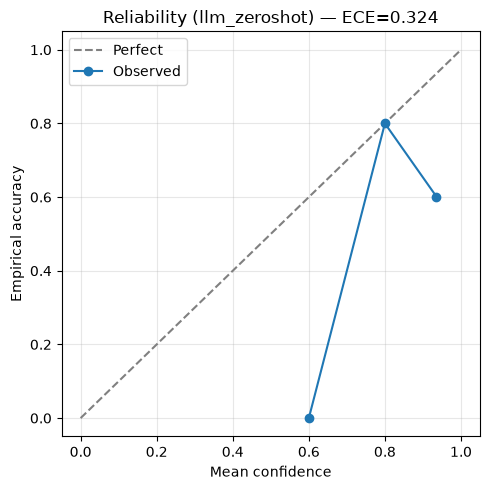


Wrote failure_analysis_test.csv (55 rows)
Wrote confidence_calibration_test.csv
Wrote reliability_for_escalation.csv


In [45]:
# ============ CELL 14: Failure analysis + reliability ============
import matplotlib.pyplot as plt

# --- Misclassified test rows ---
preds_test = pd.read_json(FINAL_PREDS, orient="records", lines=True)
wrong = preds_test[preds_test["true_intent"] != preds_test["pred_intent"]]

print(f"Test errors: {len(wrong)} / {len(preds_test)}")
print("\nTop confusion pairs:")
pairs = (wrong.groupby(["true_intent", "pred_intent"])
              .size().rename("n").sort_values(ascending=False).head(15))
print(pairs.to_string())

# --- Confidence calibration (reliability + ECE) ---
conf = preds_test["confidence"].values
correct = (preds_test["true_intent"] == preds_test["pred_intent"]).values

# NEW: inline _ece (replaces the buggy `ece(...)` call)
def _ece(confs, correct, n_bins=10):
    confs = np.asarray(confs, dtype=float)
    correct = np.asarray(correct, dtype=bool)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    total = len(confs)
    if total == 0:
        return 0.0
    ece_sum = 0.0
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        if i < n_bins - 1:
            mask = (confs >= lo) & (confs < hi)
        else:
            mask = (confs >= lo) & (confs <= hi)
        n = int(mask.sum())
        if n == 0:
            continue
        mc = float(confs[mask].mean())
        ea = float(correct[mask].mean())
        ece_sum += (n / total) * abs(mc - ea)
    return float(ece_sum)

ece_val = _ece(conf, correct, n_bins=10)
rel = reliability_table(conf, correct, n_bins=10)
rel.to_csv(RUNS_CLASSIFIER / "confidence_calibration_test.csv", index=False)

print(f"\nECE (test): {ece_val:.3f}")
print(rel.to_string(index=False))

# --- Reliability diagram ---
fig, ax = plt.subplots(figsize=(5, 5))
valid = rel.dropna(subset=["mean_conf"])
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
ax.plot(valid["mean_conf"], valid["emp_acc"], marker="o", label="Observed")
ax.set_xlabel("Mean confidence")
ax.set_ylabel("Empirical accuracy")
ax.set_title(f"Reliability ({WINNER}) — ECE={ece_val:.3f}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "classifier_reliability_test.png", dpi=120)
plt.show()

# --- Save failure rows ---
cols = ["root_id", "true_intent", "pred_intent", "confidence",
        "alternative_intent", "alternative_confidence", "_source"]
wrong[cols].to_csv(RUNS_CLASSIFIER / "failure_analysis_test.csv",
                   index=False, quoting=1, encoding="utf-8")
print(f"\nWrote failure_analysis_test.csv ({len(wrong)} rows)")
print(f"Wrote confidence_calibration_test.csv")

rel.to_csv(RUNS_CLASSIFIER / "reliability_for_escalation.csv", index=False)
print("Wrote reliability_for_escalation.csv")

In [44]:
# ============ CELL 15: Handoff ============
handoff = {
    "from_notebook":  "04_classifier.ipynb",
    "to_notebook":    "05_retrieval.ipynb",
    "consumes": [
        "runs/classifier/predictions_dev.jsonl",
        "runs/classifier/predictions_test.jsonl",
        "runs/classifier/final_metrics.json",
        "runs/classifier/chosen.json",
    ],
    "does_not_rerun_classification": True,
    "verification_required_by_05": {
        "taxonomy_sha256":  tax_sha,
        "golden_sha256":    golden_sha,
        "chosen_sha":       chosen_sha,
        "test_preds_sha256": json.loads(FINAL_METRICS.read_text())["test_preds_sha256"],
        "model_id":         json.loads(CHOSEN_PATH.read_text())["model_meta"].get("model", "n/a"),
    },
    "headline_metrics": {
        "operational_macro_f1": m_op,
        "all_class_macro_f1":   m_all["macro_f1"],
        "weighted_f1":          m_all["weighted_f1"],
        "accuracy":             m_all["accuracy"],
    },
    "notes": (
        "Test was evaluated once and locked. Confidences are suitable as "
        "escalation signals in 06_agent. `alternative_intent` and "
        "`alternative_confidence` support margin-based abstention. "
        "The test prediction file is the sole source of test-time classifier "
        "output for downstream notebooks."
    ),
}
(RUNS_CLASSIFIER / "handoff_to_05.json").write_text(
    json.dumps(handoff, indent=2), encoding="utf-8"
)

print("=" * 60)
print("CLASSIFIER COMPLETE")
print("=" * 60)
print(f"Chosen approach:        {WINNER}")
print(f"Operational macro F1:   {m_op:.3f}")
print(f"All-class macro F1:     {m_all['macro_f1']:.3f}")
print(f"Weighted F1:            {m_all['weighted_f1']:.3f}")
print(f"Accuracy:               {m_all['accuracy']:.3f}")
print()
print(f"Artifacts:              {RUNS_CLASSIFIER.relative_to(PROJECT_ROOT)}/")
print(f"Handoff:                {RUNS_CLASSIFIER / 'handoff_to_05.json'}")
print()
print("Do NOT re-run test. TEST_LOCK.json enforces this.")

CLASSIFIER COMPLETE
Chosen approach:        llm_zeroshot
Operational macro F1:   0.624
All-class macro F1:     0.551
Weighted F1:            0.590
Accuracy:               0.604

Artifacts:              runs\classifier/
Handoff:                D:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\classifier\handoff_to_05.json

Do NOT re-run test. TEST_LOCK.json enforces this.
